# Muon depth profiles and $X_{max}$

Where in the atmosphere are the muons? MCEq can store its solution at
intermediate depths while it integrates down through the atmosphere. This
notebook turns those snapshots into the muon flux along the path, the
*longitudinal profile*, and reads off the depth where it peaks, $X_{max}$.

Depth is the slant depth $X$ in g/cm²: the mass of air the shower has passed
through along its direction. It is 0 at the top of the atmosphere and about
1030 g/cm² at sea level for a vertical shower, more for inclined directions.

In [1]:
import crflux.models as pm
import matplotlib.pyplot as plt
import numpy as np

from MCEq.core import MCEqRun

mceq = MCEqRun(
    interaction_model="SIBYLL2.3E",
    primary_model=(pm.HillasGaisser2012, "H3a"),
    theta_deg=0.0,
)

MCEqRun::set_interaction_model(): SIBYLL23E
Interactions::clear_channel_overrides(): 0 channel overrides cleared.
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).


MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
InitialState::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)


## One profile

`solve` stores the solution at every depth in `int_grid`. The grid runs from
the top of the atmosphere to the ground and sets the resolution of the
profile; `muon_depth_profile` and `muon_xmax` then read the stored solutions.

In [2]:
# Depths at which the solution is stored, top of the atmosphere to ground.
# 300 points are plenty; change the count if you want a finer profile.
X_grid = np.linspace(0, mceq.density_model.max_X, 300)
mceq.solve(int_grid=X_grid)

# Flux of muons (mu+ plus mu-) above 1 GeV at each stored depth
X, n_mu = mceq.muon_depth_profile(min_energy_cutoff=1.0)

# Depth of the maximum, interpolated between grid points
xmax = mceq.muon_xmax(min_energy_cutoff=1.0)
print(f"Xmax = {xmax:.0f} g/cm^2 = {mceq.density_model.X2h(xmax) / 1e5:.1f} km altitude")

Xmax = 203 g/cm^2 = 11.8 km altitude


Plotting helper, skim it: an altitude scale on top of a slant-depth axis.

In [3]:
def altitude_axis(ax, density_model):
    """Add an altitude scale in km on top of a slant-depth axis, with ticks
    spread over the depth range that is plotted."""
    X_to_km = lambda X: density_model.X2h(np.clip(X, 1e-3, None)) / 1e5
    km_to_X = lambda h: density_model.h2X(h * 1e5)
    x_lo, x_hi = ax.get_xlim()
    ticks, x_last = [], -np.inf
    for km in [50, 40, 30, 25, 20, 15, 12, 10, 8, 6, 5, 4, 3, 2, 1, 0]:
        x = float(km_to_X(km))
        if x_lo <= x <= x_hi and x - x_last > 0.06 * (x_hi - x_lo):
            ticks.append(km)
            x_last = x
    secax = ax.secondary_xaxis("top", functions=(X_to_km, km_to_X))
    secax.set_xticks(ticks)
    secax.set_xlabel("altitude [km]")
    return secax

The profile, with $X_{max}$ marked.

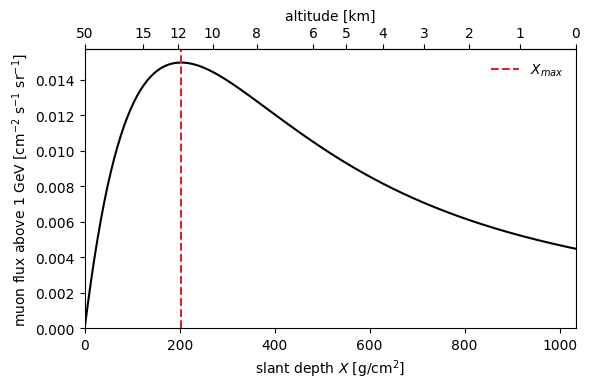

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(X, n_mu, color="k")
ax.axvline(xmax, color="C3", ls="--", label=r"$X_{max}$")
ax.set_xlim(0, X[-1])
ax.set_ylim(0, None)
ax.set_xlabel(r"slant depth $X$ [g/cm$^2$]")
ax.set_ylabel(r"muon flux above 1 GeV [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
altitude_axis(ax, mceq.density_model)
ax.legend(frameon=False)
fig.tight_layout()

## Which muons peak where

The same stored solution split into energy bands. A muon that is too slow to
reach the ground decays on the way down, so the profile of each band peaks
where production and decay balance. Each curve is normalised to its own
maximum, marked by a dot.

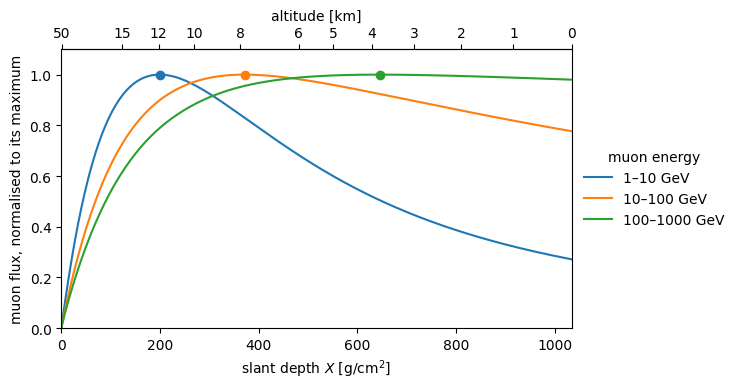

In [5]:
# Energy bands in GeV (lower edge, upper edge); change them as you like
bands = [(1, 10), (10, 100), (100, 1000)]

fig, ax = plt.subplots(figsize=(7.5, 4))
for i, (e_lo, e_hi) in enumerate(bands):
    X, n = mceq.muon_depth_profile(min_energy_cutoff=e_lo, max_energy_cutoff=e_hi)
    xmax_band = mceq.muon_xmax(min_energy_cutoff=e_lo, max_energy_cutoff=e_hi)
    ax.plot(X, n / n.max(), color=f"C{i}", label=f"{e_lo:g}–{e_hi:g} GeV")
    ax.plot(xmax_band, 1.0, "o", color=f"C{i}")
ax.set_xlim(0, X[-1])
ax.set_ylim(0, 1.1)
ax.set_xlabel(r"slant depth $X$ [g/cm$^2$]")
ax.set_ylabel("muon flux, normalised to its maximum")
altitude_axis(ax, mceq.density_model)
ax.legend(frameon=False, title="muon energy", loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()

## $X_{max}$ against zenith angle

One solve per zenith angle. The same slant depth lies at a higher altitude
on an inclined path, so the maximum is shown both ways.

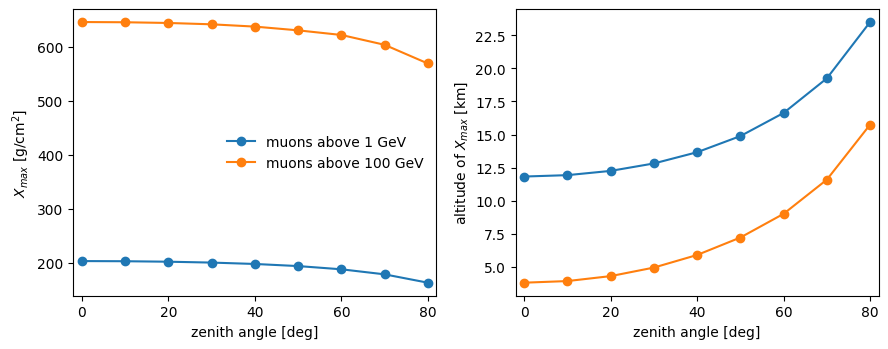

In [6]:
# Zenith angles in degrees (0 = vertical, the atmosphere reaches to 90) and
# muon energy thresholds in GeV; pick any you like
zenith_angles = np.arange(0, 81, 10)
thresholds = [1, 100]

xmax_deg = {e_min: [] for e_min in thresholds}
altitude_km = {e_min: [] for e_min in thresholds}
for theta in zenith_angles:
    mceq.set_zenith_azimuth(theta)
    # The depth to the ground grows with the zenith angle, so the grid is remade per angle
    mceq.solve(int_grid=np.linspace(0, mceq.density_model.max_X, 300))
    for e_min in thresholds:
        x = mceq.muon_xmax(min_energy_cutoff=e_min)
        xmax_deg[e_min].append(x)
        altitude_km[e_min].append(mceq.density_model.X2h(x) / 1e5)

fig, (ax_x, ax_h) = plt.subplots(1, 2, figsize=(9, 3.6))
for e_min in thresholds:
    ax_x.plot(zenith_angles, xmax_deg[e_min], "o-", label=f"muons above {e_min:g} GeV")
    ax_h.plot(zenith_angles, altitude_km[e_min], "o-")
ax_x.set_ylabel(r"$X_{max}$ [g/cm$^2$]")
ax_h.set_ylabel(r"altitude of $X_{max}$ [km]")
for ax in (ax_x, ax_h):
    ax.set_xlabel("zenith angle [deg]")
    ax.set_xlim(-2, 82)
ax_x.legend(frameon=False)
fig.tight_layout()

## A single shower at $10^{19}$ eV

The profiles above are for the whole cosmic-ray flux. `set_single_primary_particle`
replaces it by one nucleus of a given energy, which is closer to what an
air-shower array such as the Pierre Auger Observatory sees: one shower at a
time. Auger measures where the muons are *produced*, the muon production
depth distribution, and fits it with a Gaisser-Hillas function to get
$X^\mu_{max}$. `definition="production"` gives that distribution and
`muon_xmax` does the same fit. Proton and iron primaries of the same energy
at 60°, the kind of inclined shower that analysis uses.

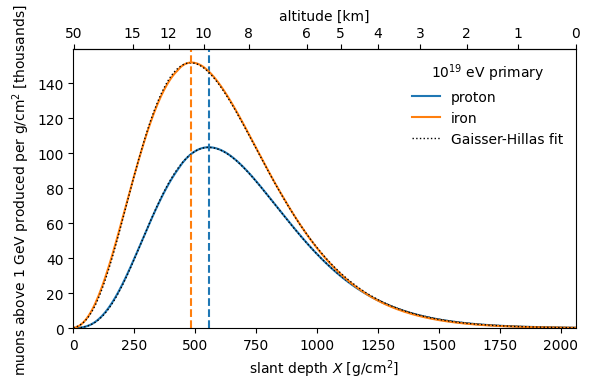

In [7]:
from MCEq.driver.observables import fit_gaisser_hillas, gaisser_hillas

# Primary energy in GeV (1e10 GeV = 1e19 eV) and the primaries by CORSIKA id
# (A*100 + Z; 14 is the proton) and the zenith angle; change them as you like
E_primary = 1e10
primaries = {"proton": 14, "iron": 5626}
zenith = 60.0

mceq.set_zenith_azimuth(zenith)
X_grid = np.linspace(0, mceq.density_model.max_X, 300)

fig, ax = plt.subplots(figsize=(6, 4))
for i, (name, corsika_id) in enumerate(primaries.items()):
    mceq.set_single_primary_particle(E_primary, corsika_id=corsika_id)
    mceq.solve(int_grid=X_grid)
    # Muon production rate dN/dX above 1 GeV, and its Gaisser-Hillas fit
    X, rate = mceq.muon_depth_profile(definition="production", min_energy_cutoff=1.0)
    n_max, xmax_mu, x0, lam = fit_gaisser_hillas(X, rate)
    ax.plot(X, rate * 1e-3, color=f"C{i}", label=name)
    ax.plot(X, gaisser_hillas(X, n_max, xmax_mu, x0, lam) * 1e-3, color="k", ls=":", lw=1)
    ax.axvline(xmax_mu, color=f"C{i}", ls="--")
ax.plot([], [], color="k", ls=":", lw=1, label="Gaisser-Hillas fit")
ax.set_xlim(0, X[-1])
ax.set_ylim(0, None)
ax.set_xlabel(r"slant depth $X$ [g/cm$^2$]")
ax.set_ylabel(r"muons above 1 GeV produced per g/cm$^2$ [thousands]")
altitude_axis(ax, mceq.density_model)
ax.legend(frameon=False, title=r"$10^{19}$ eV primary")
fig.tight_layout()